# MURaM Stokes data generated through NICOLE

## 0. Prerrequisites

In [1]:
import warnings
warnings.resetwarnings()
warnings.filterwarnings("ignore")  # all warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", module="pandas")
warnings.filterwarnings("ignore", module="matplotlib")

from pathlib import Path
import os
import sys
sys.path.append('/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils')
from model_prof_tools import read_prof

import numpy as np

import pandas as pd

from scipy.interpolate import interp1d
from scipy.ndimage import convolve1d

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import TwoSlopeNorm
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1 import make_axes_locatable

from tqdm import tqdm

images_dir = Path('/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/notebooks/notebooks_images/')

plt.rcParams.update({
  'axes.titlesize': 'x-large',  # heading 1
  'axes.labelsize': 'large',   # heading 2
  'xtick.labelsize': 'medium',         # fontsize of the ticks
  'ytick.labelsize': 'medium',         # fontsize of the ticks
  'font.family': 'serif',        # Font family
  'text.usetex': False,          # Do not use LaTeX for text rendering
  'figure.figsize': (10, 8),     # Default figure size
  'savefig.dpi': 300,            # High resolution for saving figures
  'savefig.format': 'png',       # Default format for saving figures
  'legend.fontsize': 'small',  # Font size for legends
  'lines.linewidth': 2,          # Line width for plots
  'lines.markersize': 8,         # Marker size for plots,
  'axes.formatter.useoffset': False,  # Disable offset
  'axes.formatter.use_mathtext': True,  # Use scientific notation
  'axes.formatter.limits': (-3, 4),  # Use scientific notation for values over 10^2
  'axes.labelsize': 'large',     # Font size for axes labels
  'figure.titlesize': 'xx-large', # Font size for suptitles (heading 1)
  'axes.formatter.use_locale': False  # Do not use locale settings
})



## 1. Charge Stokes

For a sample step we charge the corresponding stokes data associated to the MHD simulation step. It is necessary to rotate it 90 degrees and reflect it over the x axis.

In [ ]:
t_step = 112
data_dir = Path('/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/data/')
stokes_dir = data_dir / 'muram-simulation/'
stokes = np.load(stokes_dir / f"stokes_{t_step:03d}000.npy")

stokes = {"I": stokes[:,:,:,0],
          "Q": stokes[:,:,:,1],
          "U": stokes[:,:,:,2],
          "V": stokes[:,:,:,3]}
for key in stokes.keys():
    stokes[key] = np.flip(np.rot90(stokes[key], k=1, axes=(0,1)), axis=0)

nx = stokes["I"].shape[0]
ny = stokes["I"].shape[1]
nwl = stokes["I"].shape[2]

for key in stokes.keys():
    print(f"{key} shape: {stokes[key].shape}")


I shape: (480, 480, 300)
Q shape: (480, 480, 300)
U shape: (480, 480, 300)
V shape: (480, 480, 300)


The wavelength points generated from the simulation are $300$ spectral points of $0.01\,\text{\AA}$ beginning from $6300.5\,\text{\AA}$, containing the FeI spectral lines $6301.5\,\text{\AA}$ and $ 6302.5\,\text{\AA}$.

In [3]:
wl = np.arange(6300.5, 6303.5, 0.01)
print(f"Wavelengths from {wl[0]} to {wl[-1]} in steps of {np.round(wl[1] - wl[0], 2)} nm")

Wavelengths from 6300.5 to 6303.490000000065 in steps of 0.01 nm


## 2. Spectra normalization

First of all, let select a pixel in an intergranular zone to use as example in further experiments

In [4]:
def plot_selected_pixel(stokes: dict, test_x: int, test_y: int, 
                        images_dir: Path = images_dir, t_step: int = t_step):
    
    fig, ax = plt.subplots(figsize=(5, 5))

    # Plot the intensity (Stokes I) at the specified wavelength pixel
    data = stokes["I"][..., 0]
    im = ax.imshow(data, cmap='inferno', origin="lower")

    # Add a thick black rectangle to highlight the selected pixel
    rect = patches.Rectangle((test_y - 1.5, test_x - 1.5), 3*4, 3*4, linewidth=3, edgecolor='yellow', facecolor='none')
    ax.add_patch(rect)

    # Add colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Intensity with Highlighted Pixel")
    
    step_dir = images_dir / "sample_step"  / "stokes" / f"{t_step}_Step"
    os.makedirs(step_dir, exist_ok=True)
    fig.savefig(step_dir / "selected_pixel.png", dpi=300)
    plt.show()
    
def plot_continuum_values(wl: np.ndarray, stokes: dict, test_x: int, test_y: int, wl_cont_values, cont_values, images_dir=images_dir, t_step=t_step):
    cont_model = np.ones_like(wl)*np.mean(cont_values)

    fig, ax = plt.subplots(figsize = (7,3))
    ax.scatter(wl_cont_values, cont_values, label = "manually selected", color = "green", s = 50)
    ax.scatter(wl, stokes["I"][test_x, test_y, :], label = "original", color = "black", s = 4)
    ax.plot(wl, cont_model, label="continuum", color = "red")
    ymin = np.min(stokes["I"][test_x, test_y, :])
    ymax = np.max(stokes["I"][test_x, test_y, :])
    ax.set_ylim((ymin, ymax+ymin))
    ax.legend()

    step_dir = images_dir / "sample_step"  / "stokes" / f"{t_step}_Step"
    os.makedirs(step_dir, exist_ok=True)

    fig.savefig(step_dir / "continuum_interpolation.png", dpi=300)
    plt.show()    

def plot_stokes(ax,
                wl: np.ndarray, 
                stokes: np.ndarray, 
                test_x: int, test_y: int, 
                wl_index_range: list = None,
                scatter: bool = False,
                **kwargs):
    stokes_title_map = {"I": r"$I$", 
                        "V": r"$V/I_c$"}
    stokes_titles = [r"$I$",r"$V/I_c$"]
    for i, key in enumerate(["I","V"]):
        
        wl_to_plot = wl
        if wl_index_range is not None:
            wl_to_plot = wl[wl_index_range[0]:wl_index_range[1]]
            stokes_to_plot = stokes[key][test_x, test_y, wl_index_range[0]:wl_index_range[1]]
        else:
            stokes_to_plot = stokes[key][test_x, test_y, :]
        if scatter:
            ax[i].scatter(wl_to_plot, stokes_to_plot, **kwargs)
        else:
            ax[i].plot(wl_to_plot, stokes_to_plot, **kwargs)
        ax[i].set_title(stokes_titles[i])
        ax[i].set_xlabel("Wavelength (Å)")
        ax[i].legend()
    return ax

test_x: 373, test_y: 55


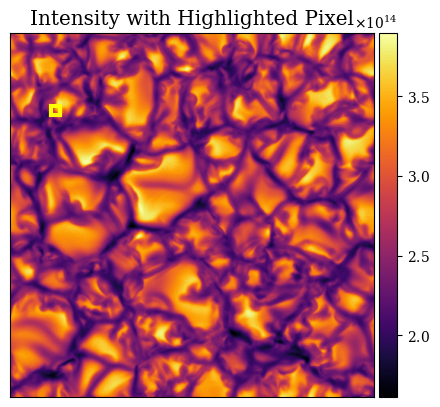

In [5]:
test_x = 373
test_y = 55

print(f"test_x: {test_x}, test_y: {test_y}")

plot_selected_pixel(stokes, test_x, test_y)


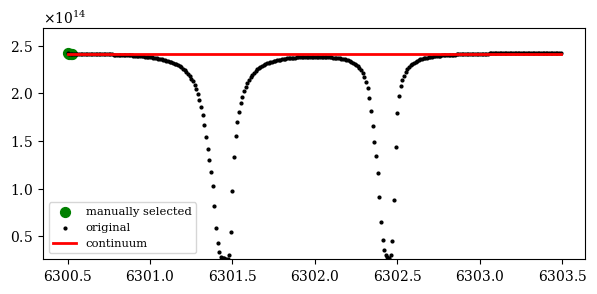

In [6]:
#Selection of the indices that we assume generally correspond to continuum in our data.
cont_indices = [0,1,2,3]


wl_cont_values = wl[cont_indices] #corresponding wavelength values to the selected continuum indices
cont_values = stokes["I"][test_x, test_y, cont_indices] #corresponding intensity values to the selected continuum indices

cont_model = np.ones_like(wl)*np.mean(cont_values)

plot_continuum_values(wl, stokes, 
                      test_x, test_y, 
                      wl_cont_values, cont_values, 
                      images_dir = images_dir, t_step=t_step)

In [7]:
def continuum_normalization(spectral_cube: np.ndarray) -> np.ndarray:
    """
    Function to normalize the spectral cube by continuum normalization.
    Args:
        spectral_cube(np.ndarray): Spectral cube to be normalized.
    Returns:
        (np.ndarray) Normalized spectral
    """
    cont_indices = [0,1,2,3]

    # Vectorized interpolation for speedup
    # cont_values = spectral_cube[:, :, cont_indices, 0].mean(axis = 2).flatten().mean()  # corresponding intensity values to the selected continuum indices
    # cont_model = interp1d(wl_cont_values, cont_values, kind="linear", axis=2)  # Interpolation applied over the assumed continuum values
    I_c =  spectral_cube["I"][:, :, cont_indices].mean(axis = 2).flatten().mean()
    
    # Apply the normalization
    #mean_continuum_image = cont_model(wl_array).mean(axis=2)
    mean_continuum_image = spectral_cube["I"][:, :, cont_indices].mean(axis = 2)
    norm_spectral_cube = {}
    for i, key in enumerate(spectral_cube.keys()):
        norm_spectral_cube[key] = spectral_cube[key] / I_c

    mean_continuum_image /= I_c
    return norm_spectral_cube, mean_continuum_image

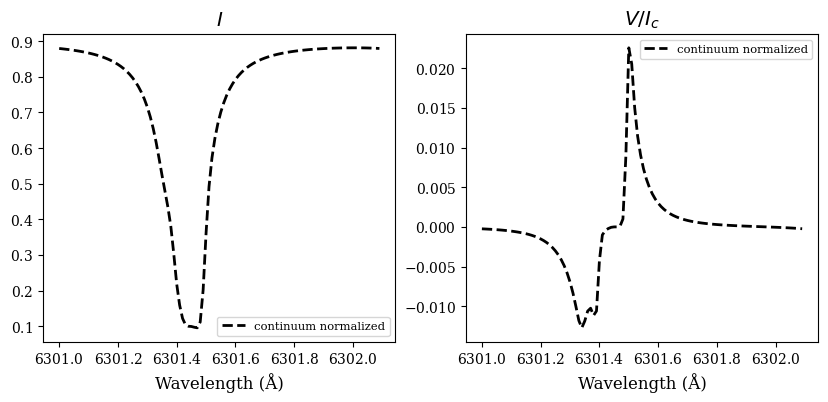

In [8]:
norm_stokes, mean_continuum = continuum_normalization(stokes)
old_mean_continuum = mean_continuum.copy()

fig, ax = plt.subplots(1,2,figsize = (10,4))
plot_stokes(ax, wl, norm_stokes, test_x, test_y, wl_index_range = [50,160], label = "continuum normalized", color = "black", linestyle="--")
plt.show()

## 3. Stokes Hinode/SOT-SP adaptation

Let's define a function for visualizing the total polarimetry for not taking just one wavelength point.

In [9]:
def check_overflow(data, name):
    """Check for NaN, inf values or extremely large numbers in data"""
    has_nan = np.isnan(data).any()
    has_inf = np.isinf(data).any()
    has_huge = (np.abs(data) > 1e30).any()
    
    if has_nan or has_inf or has_huge:
        print(f"WARNING: {name} has problems:")
        print(f"  - NaN values: {has_nan}")
        print(f"  - Inf values: {has_inf}")
        print(f"  - Extremely large values: {has_huge}")
        
        if has_nan:
            print(f"  - NaN count: {np.isnan(data).sum()}")
        if has_inf:
            print(f"  - Inf count: {np.isinf(data).sum()}")
        if has_huge:
            huge_vals = data[np.abs(data) > 1e30]
            print(f"  - Huge values: {huge_vals[:5]} ...")
        
        return True
    return False
def spectropolarimetry(stokes: np.ndarray) -> np.ndarray:
    """
    Function to calculate the polarization degree and angle from the Stokes parameters.
    Args:
        stokes(np.ndarray): Array containing the Stokes parameters.
    Returns:
        (np.ndarray) Array containing the polarization degree and angle.
    """
    nwl_points = stokes["I"].shape[-1]

    # Avoid division by zero
    epsilon = 1e-10
    I_safe = np.maximum(stokes["I"], epsilon)
    
    circular_polarization = np.sum(np.abs(stokes["V"])/I_safe, axis=-1) / nwl_points
    
    # Check for overflow
    check_overflow(circular_polarization, "circular_polarization")
    
    return circular_polarization

A common metric for analyzing the contrast in an image, that should be reduced when a PSF convolution is applied, is the RMS metric. Let's define a function for it

In [10]:
def rms_calculation(data: np.ndarray) -> float:
    return np.sqrt(np.mean((data - data.mean())**2))/data.mean()

Let's create the polarization information for the stokes without processing

In [11]:
old_norm_circular_polarization = spectropolarimetry(norm_stokes)
def plot_polarizations(mean_continuum_data: np.ndarray, 
                       circular_polarization_data: np.ndarray,
                       rms: list[float, float, float] = None,
                       images_dir: Path = images_dir, t_step: int = t_step) -> None:
    """
    Function to plot the mean continuum, linear polarization, and circular polarization.
    Args:
        mean_continuum_data(np.ndarray): Array containing the mean continuum.
        linear_polarization_data(np.ndarray): Array containing the linear polarization.
        circular_polarization_data(np.ndarray): Array containing the circular polarization.
    Returns:
        None
    """
    fig, ax = plt.subplots(1, 2, figsize=(2*4.3, 4.3))

    # Plot mean_continuum
    im1 = ax[0].imshow(mean_continuum_data, cmap='inferno', origin="lower")
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    divider1 = make_axes_locatable(ax[0])
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im1, cax=cax1)

    # Plot old_norm_circular_polarization
    q_low, q_high= np.quantile(circular_polarization_data, [0.05, 0.95])
    im3 = ax[1].imshow(old_norm_circular_polarization, cmap="PiYG", vmin=q_low, vmax=q_high, origin="lower")
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    divider3 = make_axes_locatable(ax[1])
    cax3 = divider3.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im3, cax=cax3)

    if rms:
        ax[0].set_title(f'Continuum (rms = {rms[0]:.2f})')
        ax[1].set_title(f'Circular Pol. (rms = {rms[1]:.2f})')
    else:
        ax[0].set_title('Continuum')
        ax[1].set_title('Circular Pol.')

    plt.tight_layout()
    step_dir = images_dir / "sample_step"  / "stokes" / f"{t_step}_Step"
    os.makedirs(step_dir, exist_ok=True)
    plt.savefig(step_dir / "polarizations.png", dpi=300)

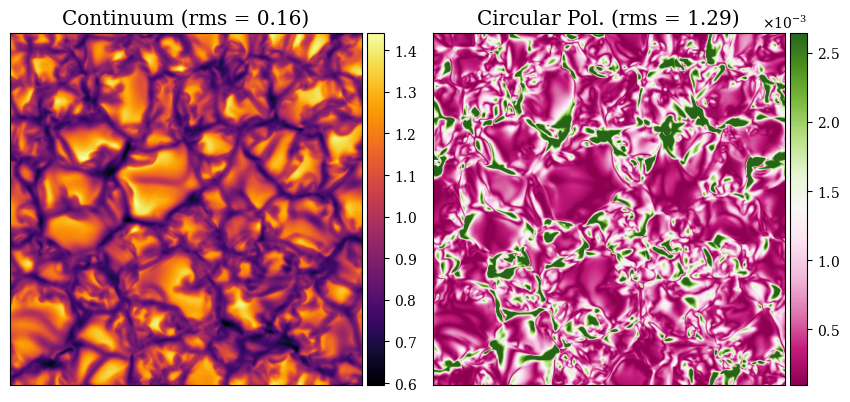

In [12]:
old_rms = [rms_calculation(old_mean_continuum), rms_calculation(old_norm_circular_polarization)]
plot_polarizations(mean_continuum, old_norm_circular_polarization, old_rms)

### 3.1 Degrading spectral resolution

In [13]:
hinode_dir = data_dir / "hinode-MODEST"

# Reading the LSF data from the Hinode PSF file
lsf_hinode = pd.read_csv(hinode_dir / "PSFs" / "hinode_sp.spline.psf", sep = "\s+", header = None)

# Interpolation of the LSF to match the wavelength grid of the MURaM data
lsf_wavelengths = lsf_hinode[0].values
lsf_values = lsf_hinode[1].values
lsf_interp = interp1d(lsf_wavelengths, lsf_values, kind = "cubic") 

# Wavelength range for the LSF kernel after trimming 0.01 nm from each end
lsf_wl_min = np.round(lsf_wavelengths.min()+0.010, 3)
lsf_wl_max = np.round(lsf_wavelengths.max()-0.010, 3)

# New wavelength grid for the LSF kernel
step = wl[1] - wl[0]
new_kernel_wl = np.arange(lsf_wl_min, lsf_wl_max+step, step) #We are assuming that the values of the LSF are presented in amstrongs.
new_kernel_values = lsf_interp(new_kernel_wl)

# Normalization of the kernels
lsf_values = lsf_values / lsf_values.sum()
new_kernel_values = new_kernel_values / new_kernel_values.sum()

print(f"LSF wavelengths range: {lsf_wl_min:0.3f} - {lsf_wl_max:0.3f}")


LSF wavelengths range: -0.060 - 0.060


Convolve your stokes signal for each stokes on this lsf kernel

In [14]:
stokes_sptrl_convolved = {}

# Apply convolution for each Stokes parameter efficiently

for key in stokes.keys():
    stokes_sptrl_convolved[key] = convolve1d(
        stokes[key],               # Input: (nx, ny, n_lambda)
        weights=new_kernel_values,     # Kernel
        axis=-1,                       # Apply along wavelength axis
        mode='wrap'                    # Mimic periodic boundary as before
    )

Equivalent Width without LSF for the tested pixel: 0.33 Å
Equivalent Width with LSF for the tested pixel: 0.33 Å


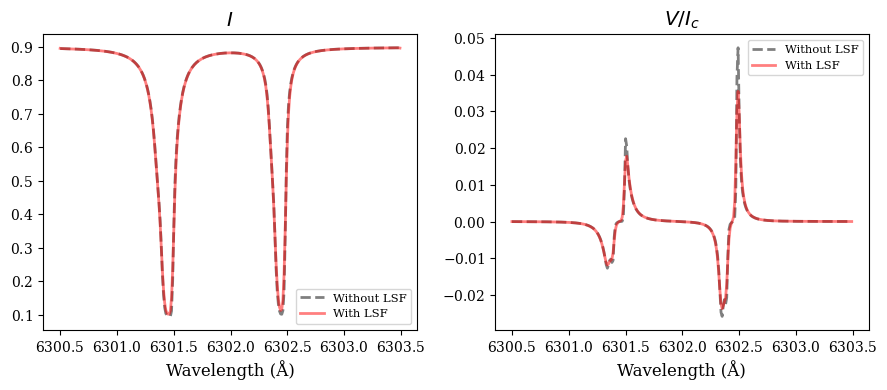

In [15]:
# Normalize the spectrally convolved data for visualization
norm_stokes_sptrl_convolved, _ = continuum_normalization(stokes_sptrl_convolved)

fig, ax = plt.subplots(1,2,figsize = (9,4))
plot_stokes(ax, wl, norm_stokes, test_x, test_y, label = "Without LSF", alpha=0.5, color="k", linestyle="--")
plot_stokes(ax, wl, norm_stokes_sptrl_convolved, test_x, test_y, label = "With LSF", alpha=0.5, color="red", linestyle="-")
fig.tight_layout(w_pad=1.0, h_pad=2)

# Calculate Equivalent Width for Stokes I without LSF
continuum_level = stokes["I"][test_x, test_y].max()
equivalent_width_without_lsf = np.trapz(1 - stokes["I"][test_x, test_y, :] / continuum_level, wl)
print(f"Equivalent Width without LSF for the tested pixel: {equivalent_width_without_lsf:.2f} Å")

# Calculate Equivalent Width for Stokes I with LSF
continuum_level_convolved = stokes_sptrl_convolved["I"][test_x, test_y].max()
equivalent_width_with_lsf = np.trapz(1 - stokes_sptrl_convolved["I"][test_x, test_y, :] / continuum_level_convolved, wl)
print(f"Equivalent Width with LSF for the tested pixel: {equivalent_width_with_lsf:.2f} Å")

plt.show()

### 3.3 Spectral sampling

The spectral resolution on satellites doing spectropolarimetric measurements on the sun has, at best, 112 points of spectral resolution. This is the case for Hinode/SOT-SP, where the instrument information state in [Lites et al. 2013 (Solar Physics, 283, 579–599)](https://link.springer.com/article/10.1007/s11207-012-0206-3) that 
In this key paper (and related instrument papers), it's stated:

The Hinode/SP observes a spectral window centered near 6302 Å, specifically chosen to include:
- Fe I 6301.5 Å
- Fe I 6302.5 Å

The sampling is about 21.5 mÅ per pixel, covering 112 wavelength points, giving approximately 2.4 Å total range.

In [16]:
# Parameters from Hinode/SP FITS header (typical values)
NAXIS1 = 112
CRVAL1 = 6302.0    # Ångstroms
CDELT1 = 0.0215    # Å/pixel
CRPIX1 = 57        # Reference pixel

# Wavelength array calculation
new_wl = CRVAL1 + (np.arange(1, NAXIS1 + 1) - CRPIX1) * CDELT1

print("Interpolating Stokes parameters to Hinode/SP wavelengths...")

# Create an array to store the interpolated values
stokes_to_hinode_wl = {}
for key in stokes.keys():
    stokes_reshaped = stokes_sptrl_convolved[key].reshape(-1, stokes_sptrl_convolved[key].shape[2])
    stokes_to_hinode_wl[key] = interp1d(wl, stokes_reshaped, kind="cubic", axis=1)(new_wl).reshape(nx, ny, NAXIS1)

# Normalize the interpolated data
norm_stokes_to_hinode_wl, mean_continuum_stokes_to_hinode_wl = continuum_normalization(stokes_to_hinode_wl)
circular_polarimetry_to_hinode_wl = spectropolarimetry(norm_stokes_to_hinode_wl)

Interpolating Stokes parameters to Hinode/SP wavelengths...


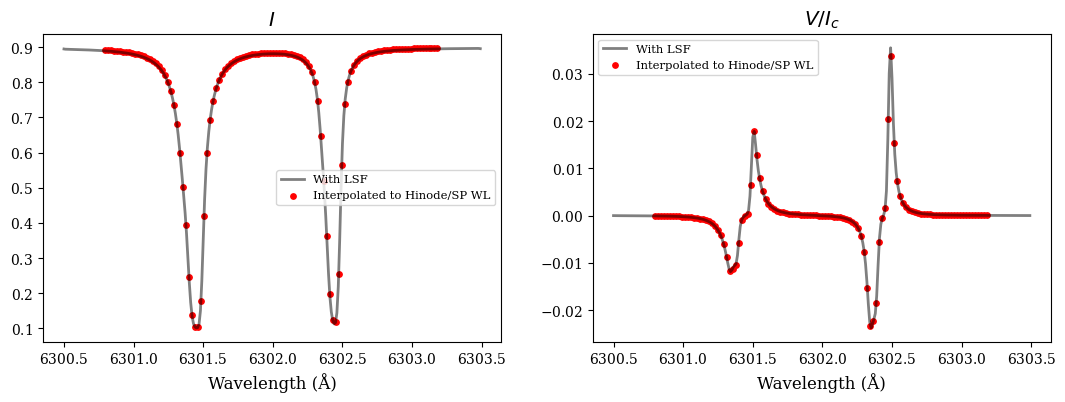

In [17]:
fig, ax = plt.subplots(1,2,figsize = (13,4))
plot_stokes(ax, wl, norm_stokes_sptrl_convolved, test_x, test_y, label = "With LSF", alpha=0.5, color="black", linestyle="-")
plot_stokes(ax, new_wl, norm_stokes_to_hinode_wl, test_x, test_y, scatter=True, label = "Interpolated to Hinode/SP WL", color="red", s=15)
plt.show()

### 3.4 Adding noise (OPTIONAL)

Hinode data has, according to the paper of MODEST, $\sigma \approx  5.9 \times 10^{-4}\,I_c$. Let's add this noise to the our data.

In [18]:
# Add Gaussian noise to the resampled Stokes cube
I_c = mean_continuum_stokes_to_hinode_wl.flatten().mean()
level_of_noise = 5.9e-4 * I_c

norm_stokes_with_noise = {}
mean_continuum_with_noise = {}

for key in stokes.keys():
    # Generate noise with full shape (nx, ny, NAXIS1) for independent noise at each pixel
    noise = level_of_noise * I_c * np.random.randn(nx, ny, NAXIS1)
    norm_stokes_with_noise[key] = norm_stokes_to_hinode_wl[key] + noise

mean_continuum_with_noise = mean_continuum_stokes_to_hinode_wl + level_of_noise * I_c * np.random.randn(1)[0]
circular_polarization_with_noise = spectropolarimetry(norm_stokes_with_noise)

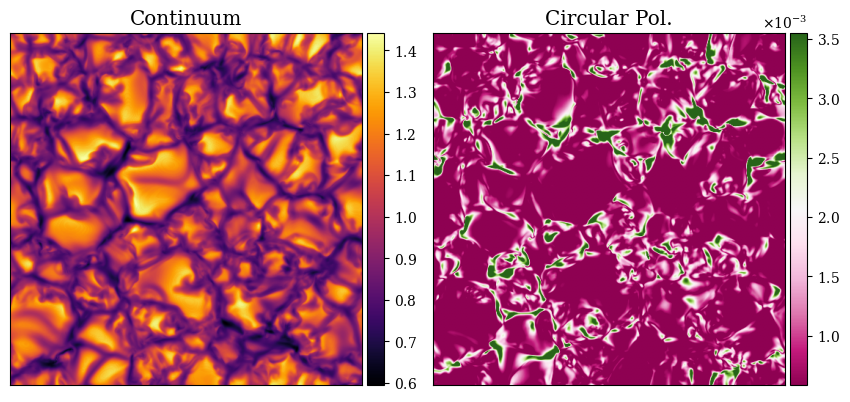

In [19]:
plot_polarizations(mean_continuum_with_noise, circular_polarization_with_noise)

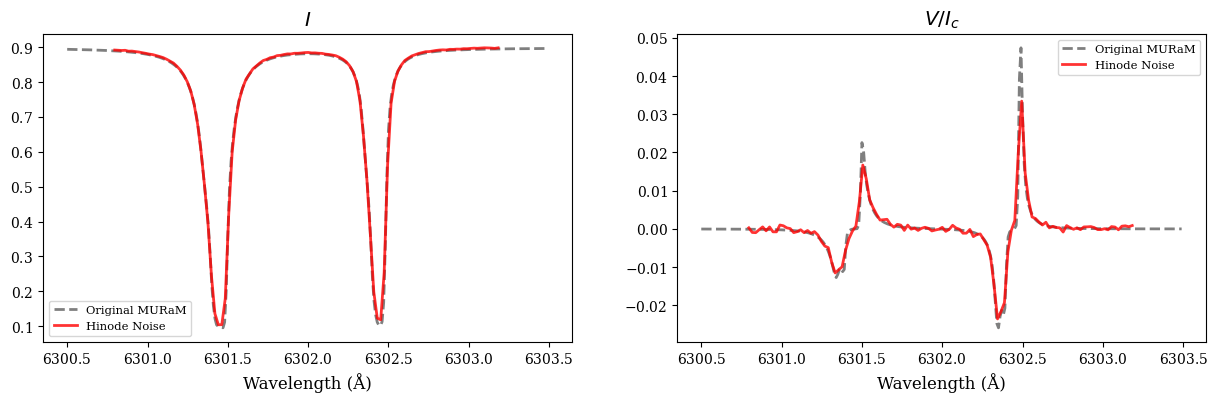

In [20]:
fig, ax = plt.subplots(1,2,figsize = (15,4))
plot_stokes(ax, wl, norm_stokes, test_x, test_y, label = "Original MURaM", color="black", linestyle="--", alpha=0.5)
plot_stokes(ax, new_wl, norm_stokes_with_noise, test_x, test_y, label = "Hinode Noise", alpha=0.8, color="red")
plt.show()